# Phase 5 — SegFormer Training

**Architecture**: SegFormer-B1 (`nvidia/mit-b1`) — hierarchical Mix Transformer encoder + lightweight MLP decode head.

**Adaptation for BraTS**: The first patch embedding projection is expanded from 3 → 4 input channels (T1c, T1n, T2f, T2w). The new channel is initialised as the mean of the three RGB channels to preserve pretrained feature responses.

**Training strategy** (mirrors U-Net baseline exactly):
- Phase 1 (5 epochs): encoder frozen, decoder trained at LR=3e-4
- Phase 2 (25 epochs): full fine-tuning, differential LR (encoder 1e-5 / decode_head 1e-4)

**Loss**: `CombinedLoss` (Dice + Focal, weights=1.0 each, γ=2.0, ignore_background=True)  
**Optimiser**: AdamW + CosineAnnealingLR, batch size 16, center crop 192×192, AMP enabled

## 1 — Imports & Reproducibility

In [1]:
import os
import sys
import json
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import transformers

# Add project root to path so `src` is importable
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import BraTSDataset
from src.losses import CombinedLoss
from src.models import get_segformer
from src.train_utils import (
    get_augmentation,
    get_class_weights,
    train_one_epoch,
    evaluate,
    set_encoder_trainable,
    save_checkpoint,
    load_checkpoint,
    format_metrics,
    center_crop,
)

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")

PyTorch      : 2.11.0+cu128
Transformers : 5.6.2
CUDA         : True


## 2 — Configuration

In [2]:
# ── Paths ───────────────────────────────────────────────────────────────────
DATA_DIR  = PROJECT_ROOT / "processed_dataset"
CKPT_DIR  = PROJECT_ROOT / "checkpoints" / "segformer"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT = str(CKPT_DIR / "best.pth")
LAST_CKPT = str(CKPT_DIR / "last.pth")

# ── Model ───────────────────────────────────────────────────────────────────
MODEL_CHECKPOINT = "nvidia/mit-b1"   # HuggingFace model ID
NUM_CLASSES      = 4                 # 0=BG, 1=NCR, 2=ED, 3=ET
IN_CHANNELS      = 4                 # t1c, t1n, t2f, t2w
CROP_SIZE        = 192

# ── Training ────────────────────────────────────────────────────────────────
BATCH_SIZE        = 16
NUM_WORKERS       = 4
PIN_MEMORY        = True

PHASE1_EPOCHS     = 5     # encoder frozen
PHASE2_EPOCHS     = 25    # full fine-tuning
TOTAL_EPOCHS      = PHASE1_EPOCHS + PHASE2_EPOCHS

LR_PHASE1         = 3e-4  # higher LR: only decode_head is trained
LR_PHASE2         = 1e-4  # lower LR: full model, prevent catastrophic forgetting
WEIGHT_DECAY      = 1e-4

# ── Loss ────────────────────────────────────────────────────────────────────
DICE_WEIGHT       = 1.0
FOCAL_WEIGHT      = 1.0
FOCAL_GAMMA       = 2.0
IGNORE_BACKGROUND = True  # exclude class-0 from Dice average

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── AMP (mixed precision) ───────────────────────────────────────────────────
USE_AMP = DEVICE.type == "cuda"

print(f"Device       : {DEVICE}")
print(f"AMP          : {USE_AMP}")
print(f"Crop         : {CROP_SIZE}×{CROP_SIZE}")
print(f"Epochs       : {PHASE1_EPOCHS} (frozen) + {PHASE2_EPOCHS} (fine-tune) = {TOTAL_EPOCHS}")
print(f"Checkpoints  → {CKPT_DIR}")

Device       : cuda
AMP          : True
Crop         : 192×192
Epochs       : 5 (frozen) + 25 (fine-tune) = 30
Checkpoints  → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\segformer


## ✅ Pre-flight Sanity Check

Run this cell before training.  
Three independent tests — each prints **PASS** or **FAIL**.  
All three must pass before starting the training loop.

In [3]:
# =============================================================================
# PRE-FLIGHT SANITY CHECK
# Self-contained: creates its own mini model/loader/loss — no dependency on
# subsequent cells. Run before the training loop to confirm the full
# pipeline is wired correctly and CUDA is active.
# =============================================================================

import traceback

_PASS = "  ✅  PASS"
_FAIL = "  ❌  FAIL"
_all_passed = True

# Force GPU — override DEVICE in case config cell ran before CUDA was available
DEVICE = torch.device("cuda")
USE_AMP = True

# ─────────────────────────────────────────────────────────────────────────────
# TEST 1 — Hardware Check
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("TEST 1 — Hardware / CUDA")
print("=" * 60)
try:
    assert torch.cuda.is_available(), "torch.cuda.is_available() returned False"

    gpu_name   = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    vram_alloc = torch.cuda.memory_allocated(0) / 1024**3

    print(f"  GPU name       : {gpu_name}")
    print(f"  VRAM total     : {vram_total:.2f} GB")
    print(f"  VRAM allocated : {vram_alloc:.3f} GB")
    print(_PASS)
except Exception as e:
    print(f"  Error: {e}")
    print(_FAIL)
    _all_passed = False

# ─────────────────────────────────────────────────────────────────────────────
# TEST 2 — DataLoader Check
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("TEST 2 — DataLoader (one batch from training split)")
print("=" * 60)
_batch_images = None
_batch_masks  = None
try:
    _check_ds     = BraTSDataset(str(DATA_DIR / "train"), augment=get_augmentation(p=0.5))
    _check_loader = DataLoader(_check_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    _batch_images, _batch_masks = next(iter(_check_loader))

    print(f"  images — shape : {tuple(_batch_images.shape)}  dtype : {_batch_images.dtype}")
    print(f"  masks  — shape : {tuple(_batch_masks.shape)}   dtype : {_batch_masks.dtype}")
    print(f"  images — range : [{_batch_images.min():.3f}, {_batch_images.max():.3f}]")
    print(f"  masks  — unique labels : {_batch_masks.unique().tolist()}")

    assert _batch_images.shape == (BATCH_SIZE, IN_CHANNELS, 240, 240), \
        f"Unexpected image shape: {_batch_images.shape}"
    assert _batch_masks.shape  == (BATCH_SIZE, 240, 240), \
        f"Unexpected mask shape: {_batch_masks.shape}"
    assert _batch_images.dtype == torch.float32, "Images should be float32"
    assert _batch_masks.dtype  == torch.int64,   "Masks should be int64"

    print(_PASS)
except Exception as e:
    traceback.print_exc()
    print(_FAIL)
    _all_passed = False

# ─────────────────────────────────────────────────────────────────────────────
# TEST 3 — Single-Step Training Check (SegFormer)
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("TEST 3 — Forward pass + loss + backward + optimizer step (SegFormer)")
print("=" * 60)
try:
    assert _batch_images is not None, "TEST 2 must pass before TEST 3"

    # Mini model (same architecture used in training)
    _check_model = get_segformer(MODEL_CHECKPOINT, num_classes=NUM_CLASSES).to(DEVICE)

    _check_criterion = CombinedLoss(
        num_classes=NUM_CLASSES,
        dice_weight=DICE_WEIGHT,
        focal_weight=FOCAL_WEIGHT,
        gamma=FOCAL_GAMMA,
        ignore_background=IGNORE_BACKGROUND,
        class_weights=get_class_weights(device="cpu").tolist(),
    ).to(DEVICE)

    _check_optimizer = torch.optim.AdamW(
        [p for p in _check_model.parameters() if p.requires_grad],
        lr=LR_PHASE1,
        weight_decay=WEIGHT_DECAY,
    )

    # Move batch to device and center-crop
    _imgs = _batch_images.to(DEVICE)
    _msks = _batch_masks.to(DEVICE)
    _imgs, _msks = center_crop(_imgs, _msks, CROP_SIZE)

    print(f"  Cropped input  — image: {tuple(_imgs.shape)}  mask: {tuple(_msks.shape)}")

    # Forward
    _check_optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
        _logits = _check_model(_imgs)
    print(f"  Logits shape   : {tuple(_logits.shape)}")

    # Loss (compute outside autocast for stability)
    _logits_full = _logits.float()
    _total, _d, _f = _check_criterion(_logits_full, _msks)
    print(f"  Combined loss  : {_total.item():.6f}  "
          f"(dice={_d.item():.4f}  focal={_f.item():.4f})")

    # Backward
    _total.backward()
    _grad_norm = torch.nn.utils.clip_grad_norm_(_check_model.parameters(), max_norm=1e9)
    assert torch.isfinite(_grad_norm), f"Non-finite gradient norm: {_grad_norm}"
    print(f"  Gradient norm  : {_grad_norm.item():.4f}  (finite ✓)")

    _check_optimizer.step()

    vram_after = torch.cuda.memory_allocated(0) / 1024**3
    print(f"  VRAM after fwd : {vram_after:.3f} GB")
    print(_PASS)

    # Clean up — release GPU memory before main training
    del _check_model, _check_criterion, _check_optimizer, _logits, _logits_full
    torch.cuda.empty_cache()

except Exception as e:
    traceback.print_exc()
    print(_FAIL)
    _all_passed = False

# ─────────────────────────────────────────────────────────────────────────────
# Final verdict
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
if _all_passed:
    print("🚀  ALL TESTS PASSED — pipeline is ready for the full training run.")
else:
    print("🛑  ONE OR MORE TESTS FAILED — fix errors above before training.")
print("=" * 60)

TEST 1 — Hardware / CUDA
  GPU name       : NVIDIA GeForce RTX 3080 Laptop GPU
  VRAM total     : 8.00 GB
  VRAM allocated : 0.000 GB
  ✅  PASS

TEST 2 — DataLoader (one batch from training split)
  images — shape : (16, 4, 240, 240)  dtype : torch.float32
  masks  — shape : (16, 240, 240)   dtype : torch.int64
  images — range : [-1.448, 4.888]
  masks  — unique labels : [0, 1, 2, 3]
  ✅  PASS

TEST 3 — Forward pass + loss + backward + optimizer step (SegFormer)


[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

  Cropped input  — image: (16, 4, 192, 192)  mask: (16, 192, 192)
  Logits shape   : (16, 4, 192, 192)
  Combined loss  : 0.994903  (dice=0.9926  focal=0.0023)
  Gradient norm  : 0.0406  (finite ✓)
  VRAM after fwd : 0.255 GB
  ✅  PASS

🚀  ALL TESTS PASSED — pipeline is ready for the full training run.


## 3 — Datasets & DataLoaders

In [4]:
augment = get_augmentation(p=0.5)

train_ds = BraTSDataset(str(DATA_DIR / "train"), augment=augment)
val_ds   = BraTSDataset(str(DATA_DIR / "val"),   augment=None)
test_ds  = BraTSDataset(str(DATA_DIR / "test"),  augment=None)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Train slices : {len(train_ds):>6,}  →  {len(train_loader)} batches")
print(f"Val   slices : {len(val_ds):>6,}  →  {len(val_loader)} batches")
print(f"Test  slices : {len(test_ds):>6,}  →  {len(test_loader)} batches")

Train slices : 31,519  →  1969 batches
Val   slices :  4,009  →  251 batches
Test  slices :  4,010  →  251 batches


## 4 — Model

In [5]:
model = get_segformer(MODEL_CHECKPOINT, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

print(f"Model        : SegFormer-B1 ({MODEL_CHECKPOINT})")
print(f"Device       : {next(model.parameters()).device}")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

Model        : SegFormer-B1 (nvidia/mit-b1)
Device       : cuda:0


## 4a — Parameter Count

Full breakdown of parameter counts before any training begins.

In [6]:
# ── Full parameter count breakdown ──────────────────────────────────────────
total_params      = sum(p.numel() for p in model.parameters())
encoder_params    = sum(p.numel() for p in model.encoder.parameters())
decode_head_params = sum(p.numel() for p in model.decode_head.parameters())
other_params      = total_params - encoder_params - decode_head_params

trainable_total   = sum(p.numel() for p in model.parameters()     if p.requires_grad)
trainable_enc     = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
trainable_dec     = sum(p.numel() for p in model.decode_head.parameters() if p.requires_grad)

print("=" * 55)
print("PARAMETER COUNT SUMMARY")
print("=" * 55)
print(f"  Total parameters       : {total_params:>12,}")
print(f"  ├─ Encoder (MiT-B1)    : {encoder_params:>12,}")
print(f"  ├─ Decode head         : {decode_head_params:>12,}")
if other_params > 0:
    print(f"  └─ Other               : {other_params:>12,}")
print()
print(f"  Trainable (Phase 1)    : {trainable_dec:>12,}  (decode_head — encoder frozen)")
print(f"  Trainable (Phase 2)    : {trainable_total:>12,}  (full model — encoder unfrozen)")
print("=" * 55)

# Comparison reference
print()
print(f"  U-Net/ResNet34 total   :    24,439,940  (baseline reference)")
print(f"  SegFormer-B1 total     : {total_params:>12,}  (this model)")
compression = (1 - total_params / 24_439_940) * 100
if compression > 0:
    print(f"  Parameter reduction    : {compression:>11.1f}%")
else:
    print(f"  Parameter increase     : {-compression:>11.1f}%")

PARAMETER COUNT SUMMARY
  Total parameters       :   13,681,412
  ├─ Encoder (MiT-B1)    :   13,154,560
  ├─ Decode head         :      526,852

  Trainable (Phase 1)    :      526,852  (decode_head — encoder frozen)
  Trainable (Phase 2)    :   13,681,412  (full model — encoder unfrozen)

  U-Net/ResNet34 total   :    24,439,940  (baseline reference)
  SegFormer-B1 total     :   13,681,412  (this model)
  Parameter reduction    :        44.0%


## 5 — Loss Function & Class Weights

In [7]:
class_weights = get_class_weights(device=DEVICE)

print("Per-class weights (inverse-frequency, sum=1):")
for i, (name, w) in enumerate(zip(["BG", "NCR", "ED", "ET"], class_weights.tolist())):
    print(f"  class {i} ({name:3s}): {w:.6f}")

criterion = CombinedLoss(
    num_classes=NUM_CLASSES,
    dice_weight=DICE_WEIGHT,
    focal_weight=FOCAL_WEIGHT,
    gamma=FOCAL_GAMMA,
    ignore_background=IGNORE_BACKGROUND,
    class_weights=class_weights.cpu().tolist(),
).to(DEVICE)

Per-class weights (inverse-frequency, sum=1):
  class 0 (BG ): 0.000354
  class 1 (NCR): 0.533162
  class 2 (ED ): 0.079794
  class 3 (ET ): 0.386690


## 6 — Phase 1: Frozen Encoder Warm-up

The SegFormer encoder (Mix Transformer backbone) is frozen so pretrained ImageNet weights are not corrupted by the randomly-initialised decode head gradients in the first epochs.

In [8]:
set_encoder_trainable(model, trainable=False)

# Optimise only decode_head parameters
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR_PHASE1,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=PHASE1_EPOCHS,
    eta_min=LR_PHASE1 / 10,
)
scaler = torch.amp.GradScaler(enabled=USE_AMP)

print(f"Trainable params : {sum(p.numel() for p in trainable_params):,}")

[set_encoder_trainable] Encoder is now frozen (13,154,560 params).
Trainable params : 526,852


In [9]:
history = {"train": [], "val": []}   # list of metric-dicts per epoch
best_val_dice = -1.0

print("=" * 70)
print(f"PHASE 1 — Frozen encoder  ({PHASE1_EPOCHS} epochs, LR={LR_PHASE1})")
print("=" * 70)

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        crop_size=CROP_SIZE, scaler=scaler,
    )
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE, crop_size=CROP_SIZE,
    )
    scheduler.step()

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    # Mean foreground Dice (NCR + ED + ET)
    fg_dice = np.mean([
        val_metrics["dice_NCR"],
        val_metrics["dice_ED"],
        val_metrics["dice_ET"],
    ])

    # Save best checkpoint
    if fg_dice > best_val_dice:
        best_val_dice = fg_dice
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, epoch, val_metrics, scaler)
        tag = "  ← best"
    else:
        tag = ""

    lr_now = scheduler.get_last_lr()[0]
    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  "
          f"loss={train_metrics['loss']:.4f}  "
          f"val_loss={val_metrics['loss']:.4f}  "
          f"fg_dice={fg_dice:.4f}  "
          f"lr={lr_now:.2e}"
          f"{tag}")

save_checkpoint(LAST_CKPT, model, optimizer, scheduler, PHASE1_EPOCHS, val_metrics, scaler)
print(f"\nPhase 1 complete. Best fg Dice = {best_val_dice:.4f}")

PHASE 1 — Frozen encoder  (5 epochs, LR=0.0003)


  Epoch 01/30  loss=0.9189  val_loss=0.9161  fg_dice=0.2554  lr=2.74e-04  ← best


  Epoch 02/30  loss=0.9040  val_loss=0.9148  fg_dice=0.2151  lr=2.07e-04


  Epoch 03/30  loss=0.8915  val_loss=0.9180  fg_dice=0.4871  lr=1.23e-04  ← best


  Epoch 04/30  loss=0.2985  val_loss=0.1626  fg_dice=0.8067  lr=5.58e-05  ← best


  Epoch 05/30  loss=0.1698  val_loss=0.1576  fg_dice=0.8140  lr=3.00e-05  ← best

Phase 1 complete. Best fg Dice = 0.8140


## 7 — Phase 2: Full Fine-tuning

Encoder is unfrozen. A fresh optimiser with differential LRs is created:
- **Encoder** (pretrained MiT-B1): LR = 1e-5 (10× lower) — prevents catastrophic forgetting
- **Decode head** (newly trained): LR = 1e-4

In [10]:
set_encoder_trainable(model, trainable=True)

# Differential LR: encoder gets a lower LR than decode_head
optimizer = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(),    "lr": LR_PHASE2 * 0.1},
        {"params": model.decode_head.parameters(), "lr": LR_PHASE2},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=PHASE2_EPOCHS,
    eta_min=LR_PHASE2 / 100,
)
# Re-use same scaler (state carries over fine)

print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

[set_encoder_trainable] Encoder is now trainable (13,154,560 params).
Trainable params : 13,681,412


In [11]:
print("=" * 70)
print(f"PHASE 2 — Full fine-tuning  ({PHASE2_EPOCHS} epochs, LR={LR_PHASE2})")
print("=" * 70)

for epoch in range(PHASE1_EPOCHS + 1, TOTAL_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        crop_size=CROP_SIZE, scaler=scaler,
    )
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE, crop_size=CROP_SIZE,
    )
    scheduler.step()

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    fg_dice = np.mean([
        val_metrics["dice_NCR"],
        val_metrics["dice_ED"],
        val_metrics["dice_ET"],
    ])

    if fg_dice > best_val_dice:
        best_val_dice = fg_dice
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, epoch, val_metrics, scaler)
        tag = "  ← best"
    else:
        tag = ""

    # Current LR (encoder group)
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  "
          f"loss={train_metrics['loss']:.4f}  "
          f"val_loss={val_metrics['loss']:.4f}  "
          f"fg_dice={fg_dice:.4f}  "
          f"lr={lr_now:.2e}"
          f"{tag}")

save_checkpoint(LAST_CKPT, model, optimizer, scheduler, TOTAL_EPOCHS, val_metrics, scaler)
print(f"\nTraining complete. Best val fg Dice = {best_val_dice:.4f}")
print(f"Best checkpoint  → {BEST_CKPT}")
print(f"Last checkpoint  → {LAST_CKPT}")

PHASE 2 — Full fine-tuning  (25 epochs, LR=0.0001)


  Epoch 06/30  loss=0.1374  val_loss=0.1189  fg_dice=0.8429  lr=9.96e-06  ← best


  Epoch 07/30  loss=0.1137  val_loss=0.1175  fg_dice=0.8445  lr=9.86e-06  ← best


  Epoch 08/30  loss=0.1031  val_loss=0.1095  fg_dice=0.8534  lr=9.68e-06  ← best


  Epoch 09/30  loss=0.0958  val_loss=0.1056  fg_dice=0.8552  lr=9.44e-06  ← best


...

  Epoch 26/30  loss=0.0633  val_loss=0.1102  fg_dice=0.8469  lr=1.56e-06


  Epoch 27/30  loss=0.0630  val_loss=0.1104  fg_dice=0.8473  lr=1.32e-06


  Epoch 28/30  loss=0.0628  val_loss=0.1086  fg_dice=0.8496  lr=1.14e-06


  Epoch 29/30  loss=0.0624  val_loss=0.1098  fg_dice=0.8481  lr=1.04e-06


  Epoch 30/30  loss=0.0622  val_loss=0.1092  fg_dice=0.8488  lr=1.00e-06

Training complete. Best val fg Dice = 0.8554
Best checkpoint  → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\segformer\best.pth
Last checkpoint  → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\segformer\last.pth


## 8 — Training Curves

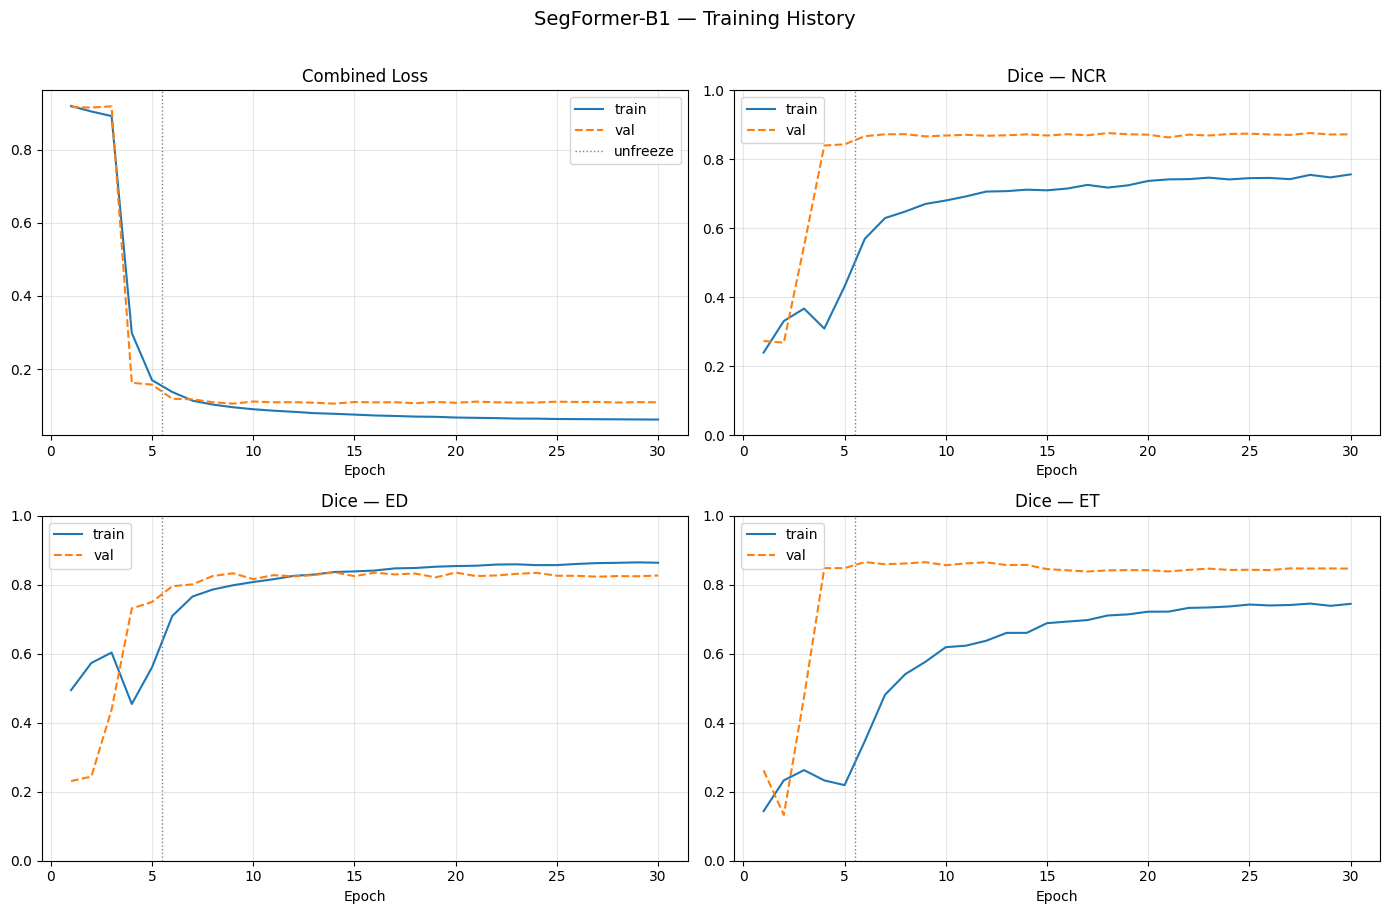

Saved → EDA_02_outputs/segformer_training_curves.png


In [12]:
epochs = list(range(1, TOTAL_EPOCHS + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("SegFormer-B1 — Training History", fontsize=14, y=1.01)

# ── Loss ────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs, [m["loss"] for m in history["train"]], label="train")
ax.plot(epochs, [m["loss"] for m in history["val"]],   label="val",   linestyle="--")
ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1, label="unfreeze")
ax.set_title("Combined Loss")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Dice per class ───────────────────────────────────────────────────────────
class_plot = [("dice_NCR", "NCR"), ("dice_ED", "ED"), ("dice_ET", "ET")]
for i, (key, label) in enumerate(class_plot):
    ax = axes[(i + 1) // 2, (i + 1) % 2]
    ax.plot(epochs, [m[key] for m in history["train"]], label="train")
    ax.plot(epochs, [m[key] for m in history["val"]],   label="val",   linestyle="--")
    ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Dice — {label}")
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_dir = PROJECT_ROOT / "EDA_02_outputs"
out_dir.mkdir(exist_ok=True)
fig.savefig(str(out_dir / "segformer_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → EDA_02_outputs/segformer_training_curves.png")

## 9 — Final Evaluation on the Test Set

In [13]:
# Reload best weights for test evaluation
ckpt = load_checkpoint(BEST_CKPT, model, device=DEVICE)
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

test_metrics = evaluate(
    model, test_loader, criterion, DEVICE, crop_size=CROP_SIZE,
)

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
for k, v in sorted(test_metrics.items()):
    print(f"  {k:<20s}: {v:.4f}")

fg_test = np.mean([test_metrics["dice_NCR"], test_metrics["dice_ED"], test_metrics["dice_ET"]])
print(f"\n  {'mean_fg_dice':<20s}: {fg_test:.4f}")

# ── Comparison with U-Net baseline ──────────────────────────────────────────
print()
print("=" * 50)
print("COMPARISON: SegFormer vs U-Net (2D test Dice)")
print("=" * 50)
unet_results = {"dice_NCR": 0.8060, "dice_ED": 0.8111, "dice_ET": 0.8202, "mean_fg": 0.8124}
print(f"  {'Metric':<20s}  {'SegFormer':>10s}  {'U-Net':>10s}  {'Delta':>10s}")
print(f"  {'-'*20}  {'-'*10}  {'-'*10}  {'-'*10}")
for cls in ["NCR", "ED", "ET"]:
    key = f"dice_{cls}"
    sf  = test_metrics[key]
    un  = unet_results[key]
    delta = sf - un
    sign = "+" if delta >= 0 else ""
    print(f"  {key:<20s}  {sf:>10.4f}  {un:>10.4f}  {sign}{delta:>9.4f}")
print(f"  {'mean_fg_dice':<20s}  {fg_test:>10.4f}  {unet_results['mean_fg']:>10.4f}  "
      f"{'+'if fg_test - unet_results['mean_fg'] >= 0 else ''}{fg_test - unet_results['mean_fg']:>9.4f}")

Loaded best checkpoint from epoch 14



TEST SET RESULTS
  dice_ED             : 0.8008
  dice_ET             : 0.8598
  dice_NCR            : 0.8580
  dice_background     : 0.9988
  dice_loss           : 0.1116
  focal_loss          : 0.0199
  loss                : 0.1315

  mean_fg_dice        : 0.8396

COMPARISON: SegFormer vs U-Net (2D test Dice)
  Metric                 SegFormer       U-Net       Delta
  --------------------  ----------  ----------  ----------
  dice_NCR                  0.8580      0.8060  +   0.0520
  dice_ED                   0.8008      0.8111    -0.0103
  dice_ET                   0.8598      0.8202  +   0.0396
  mean_fg_dice              0.8396      0.8124  +   0.0272


## 10 — Qualitative Predictions on Validation Samples

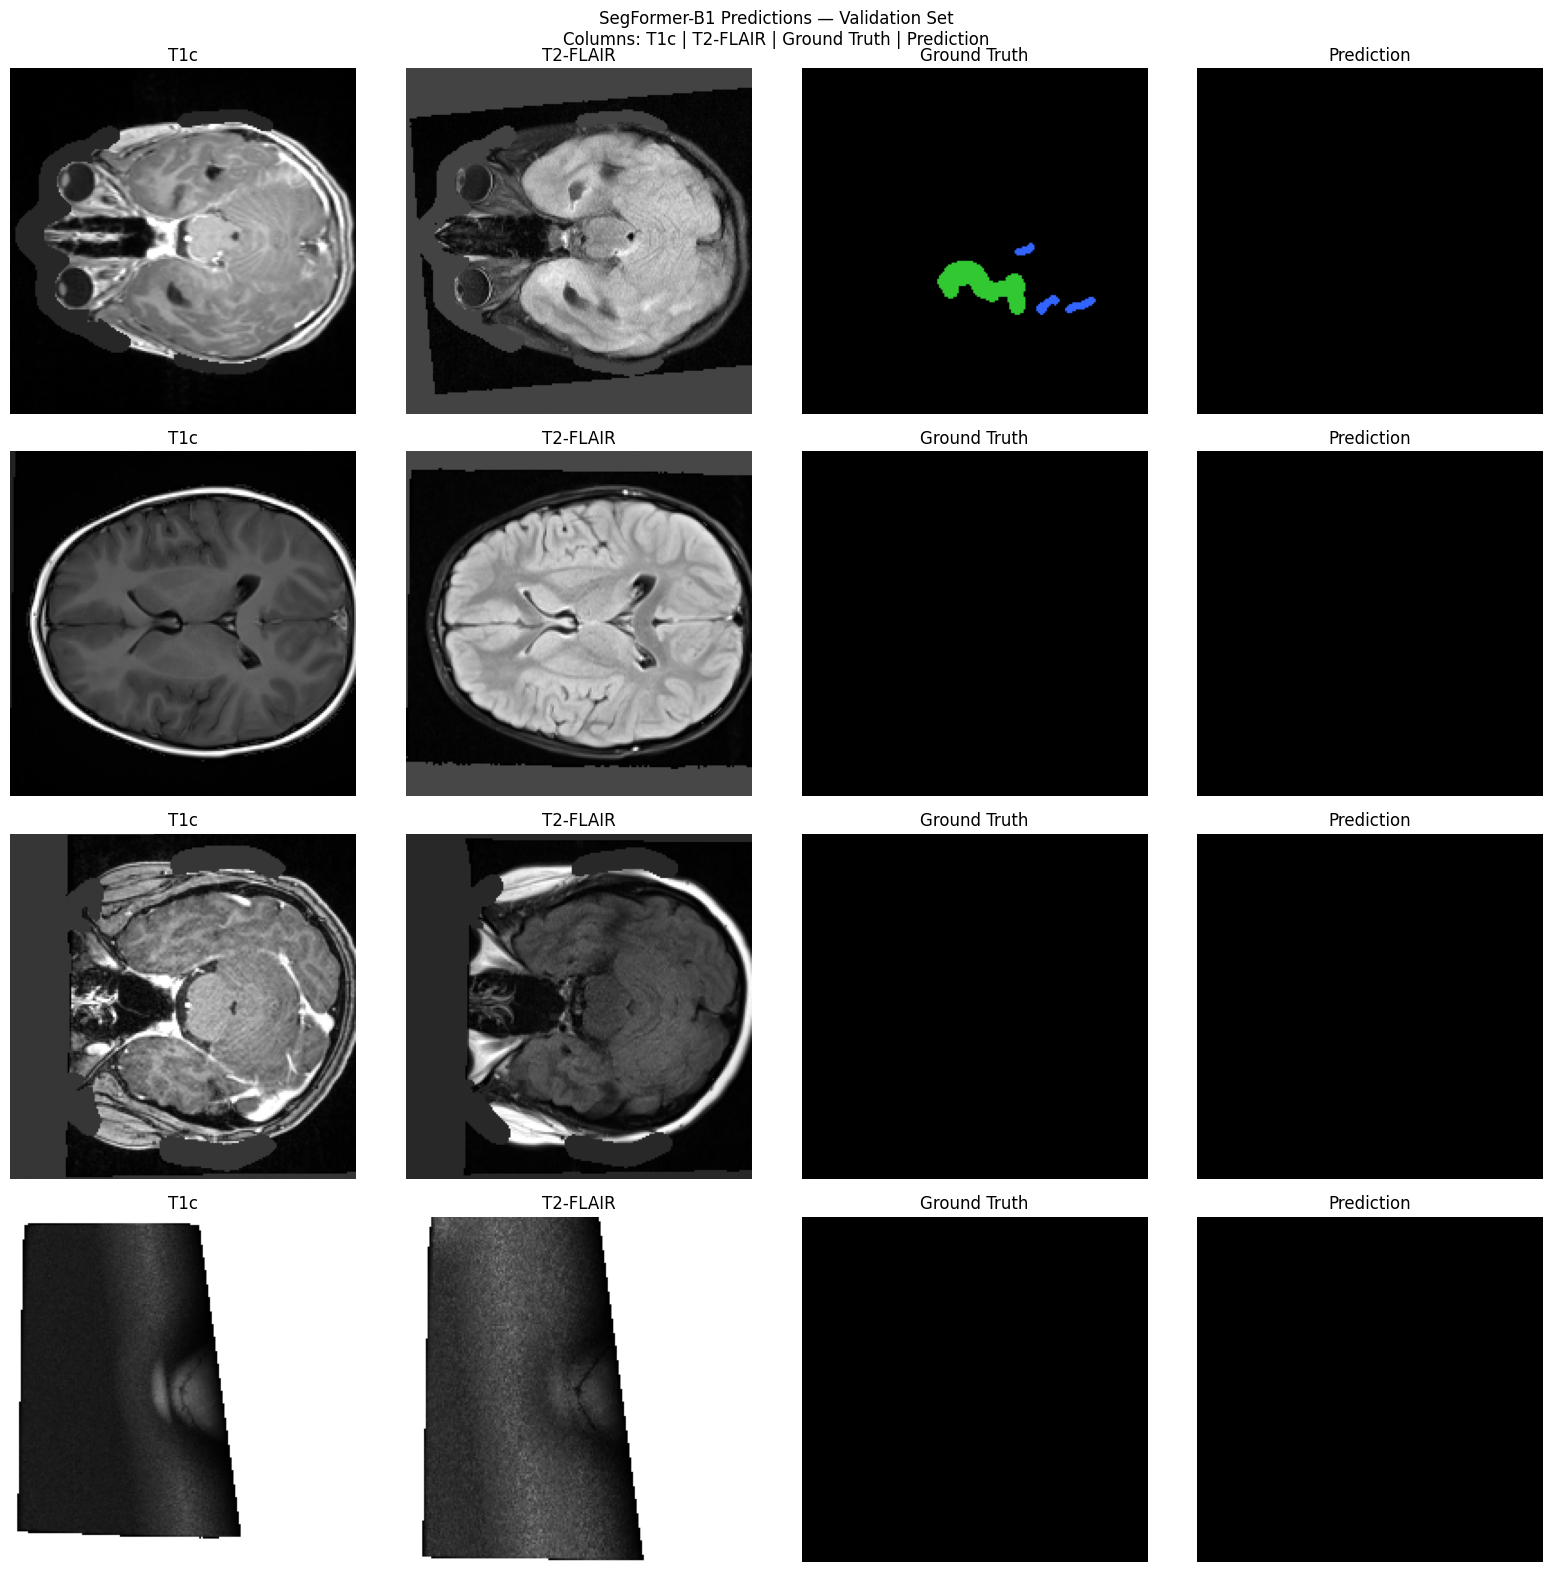

Saved → EDA_02_outputs/segformer_val_predictions.png


In [14]:
LABEL_COLORS = {
    0: [0,   0,   0  ],   # Background — black
    1: [255, 50,  50 ],   # NCR        — red
    2: [50,  200, 50 ],   # ED         — green
    3: [50,  100, 255],   # ET         — blue
}

def mask_to_rgb(mask_2d: np.ndarray) -> np.ndarray:
    """Convert integer mask [H,W] → RGB [H,W,3] for visualisation."""
    rgb = np.zeros((*mask_2d.shape, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        rgb[mask_2d == label] = color
    return rgb


model.eval()
N_SHOW = 4

single_loader = DataLoader(val_ds, batch_size=1, shuffle=True)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, N_SHOW * 4))
fig.suptitle("SegFormer-B1 Predictions — Validation Set\n"
             "Columns: T1c | T2-FLAIR | Ground Truth | Prediction",
             fontsize=12)

with torch.no_grad():
    for row, (img, mask) in enumerate(single_loader):
        if row >= N_SHOW:
            break

        img_dev  = img.to(DEVICE)
        img_crop, mask_crop = center_crop(img_dev, mask.to(DEVICE), CROP_SIZE)

        logits = model(img_crop)                             # [1, C, 192, 192]
        pred   = logits.argmax(dim=1)[0].cpu().numpy()      # [192, 192]
        gt     = mask_crop[0].cpu().numpy()                  # [192, 192]
        t1c    = img_crop[0, 0].cpu().numpy()                # [192, 192]
        t2f    = img_crop[0, 2].cpu().numpy()                # [192, 192]

        axes[row, 0].imshow(t1c, cmap="gray")
        axes[row, 0].set_title("T1c")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(t2f, cmap="gray")
        axes[row, 1].set_title("T2-FLAIR")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(mask_to_rgb(gt))
        axes[row, 2].set_title("Ground Truth")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(mask_to_rgb(pred))
        axes[row, 3].set_title("Prediction")
        axes[row, 3].axis("off")

plt.tight_layout()
fig.savefig(str(out_dir / "segformer_val_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → EDA_02_outputs/segformer_val_predictions.png")

## 11 — Save Training History (JSON)

In [15]:
history_path = str(CKPT_DIR / "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved → {history_path}")

Training history saved → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\segformer\history.json
